In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
!pip install adjustText

### Гипотеза
Наиболее продаваемые категории не обязательно являются лучшими объектами для приоритизации и дальнейшего продвижения. Более привлекательными для дополнительного маркетингового фокуса могут быть категории, которые сочетают высокую прокси-оценка коммерческого вклада, более высокую удовлетворенность клиентов и более низкий операционный риск.

### Цель проекта
Определить категории, которые одновременно сильны по коммерческим результатам и устойчивы с операционной точки зрения, и сравнить их с категориями-лидерами по выручке.

### Бизнес-эффект
Данный анализ может помочь более обоснованно приоритизировать товарные категории, учитывая не только объем продаж, но и качество экономики, клиентский опыт и устойчивость исполнения заказов.

## Подготовка данных

In [3]:
orders = pd.read_csv("C:/Users/user/Downloads/olist-project/olist_orders_dataset.csv")
order_items = pd.read_csv('C:/Users/user/Downloads/olist-project/olist_order_items_dataset.csv')
payments = pd.read_csv("C:/Users/user/Downloads/olist-project/olist_order_payments_dataset.csv")
reviews = pd.read_csv("C:/Users/user/Downloads/olist-project/olist_order_reviews_dataset.csv")
customers = pd.read_csv("C:/Users/user/Downloads/olist-project/olist_customers_dataset.csv")
products = pd.read_csv("C:/Users/user/Downloads/olist-project/olist_products_dataset.csv")
sellers = pd.read_csv("C:/Users/user/Downloads/olist-project/olist_sellers_dataset.csv")
translation = pd.read_csv("C:/Users/user/Downloads/olist-project/product_category_name_translation.csv")
products = products.merge(
    translation,
    on="product_category_name",
    how="left"
)

In [4]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

In [5]:
fact_orders = order_items.merge(orders, on="order_id", how="left")
fact_orders = fact_orders.merge(customers, on="customer_id", how="left")
fact_orders = fact_orders.merge(products, on="product_id", how="left")
fact_orders = fact_orders.merge(reviews[["order_id", "review_score"]],on="order_id",how="left")

In [60]:
payments_agg = payments.groupby("order_id", as_index=False).agg(
    payment_value=("payment_value", "sum"),
    payment_installments=("payment_installments", "max")
)
fact_orders = fact_orders.drop(
    columns=["payment_value", "payment_installments"],
    errors="ignore"
)
fact_orders = fact_orders.merge(
    payments_agg,
    on="order_id",
    how="left"
)

In [7]:
fact_orders = fact_orders[[
    "order_id",
    "order_item_id",
    "product_id",
    "seller_id",
    "customer_id",
    "customer_unique_id",
    "customer_city",
    "customer_state",
    "order_status",
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "price",
    "freight_value",
    "payment_value",
    "payment_installments",
    "review_score",
    "product_category_name",
    "product_category_name_english",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]].copy()

## Построение дополнительных признаков

Для того чтобы сравнивать категории не только по продажам, но и по качеству их бизнес-профиля, были построены дополнительные признаки, которые позволяют учитывать:

- скорость и качество доставки
- логистическую нагрузку
- упрощенную оценку коммерческого вклада определенной категории

Используются следующие производные метрики:

- `delivery_days` — количество дней между покупкой и фактической доставкой
- `delay_days` — отклонение фактической даты доставки от ожидаемой
- `is_late` — индикатор того, был ли заказ доставлен позже обещанного срока
- `freight_to_price_pct` — доля стоимости доставки в цене товара
- `contribution_proxy` — упрощенная прокси-оценка коммерческого вклада категории, рассчитанная как `price - freight_value`

Однако `contribution_proxy` не является настоящей прибылью, поскольку в датасете отсутствует полная информация о себестоимости. Эта метрика позволяет приблизительно сравнивать категории с учетом логистической нагрузки.

In [8]:
fact_orders["order_month"] = fact_orders["order_purchase_timestamp"].dt.to_period("M").astype(str)
fact_orders["delivery_days"] = (fact_orders["order_delivered_customer_date"] - fact_orders["order_purchase_timestamp"]).dt.days
fact_orders["delay_days"] = (fact_orders["order_delivered_customer_date"] - fact_orders["order_estimated_delivery_date"]).dt.days
fact_orders["is_late"] = fact_orders["delay_days"] > 0
fact_orders["freight_to_price_pct"] = (fact_orders["freight_value"] / fact_orders["price"]) * 100
fact_orders["contribution_proxy"] = fact_orders["price"] - fact_orders["freight_value"]

## Выбор доставленных заказов

Для дальнейшего анализа используются только доставленные заказы.

In [9]:
fact_delivered = fact_orders[fact_orders["order_status"] == "delivered"].copy()
fact_delivered.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id', 'customer_id',
       'customer_unique_id', 'customer_city', 'customer_state', 'order_status',
       'order_purchase_timestamp', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'price', 'freight_value',
       'payment_value', 'payment_installments', 'review_score',
       'product_category_name', 'product_category_name_english',
       'product_weight_g', 'product_length_cm', 'product_height_cm',
       'product_width_cm', 'order_month', 'delivery_days', 'delay_days',
       'is_late', 'freight_to_price_pct', 'contribution_proxy'],
      dtype='object')

## Таблица `category_summary`

В этой таблице каждая строка соответствует одной товарной категории, а столбцы отражают разные стороны ее бизнес-профиля:

- коммерческий масштаб (`orders_cnt`, `revenue`);
- экономическую привлекательность (`contribution_proxy`, `freight_to_price_pct`);
- клиентский опыт (`avg_review_score`);
- операционное качество исполнения (`avg_delivery_days`, `late_delivery_rate`).

Эта таблица нужна для того, чтобы сравнивать категории не только по объему продаж, но и по общему качеству их экономики и исполнения.

In [36]:
category_summary = fact_delivered.groupby("product_category_name_english", as_index=False).agg(
    orders_cnt=("order_id", "nunique"),
    items_cnt=("order_item_id", "count"),
    revenue=("price", "sum"),
    contribution_proxy=("contribution_proxy", "sum"),
    avg_price=("price", "mean"),
    avg_freight=("freight_value", "mean"),
    freight_to_price_pct=("freight_to_price_pct", "mean"),
    avg_review_score=("review_score", "mean"),
    avg_delivery_days=("delivery_days", "mean"),
    late_delivery_rate=("is_late", "mean")
)
category_summary["late_delivery_rate"] = category_summary["late_delivery_rate"] * 100
category_summary.sort_values("revenue", ascending=False).head(10)

category_summary = category_summary.copy()

category_summary["revenue"] = category_summary["revenue"].round(2)
category_summary["contribution_proxy"] = category_summary["contribution_proxy"].round(2)
category_summary["avg_price"] = category_summary["avg_price"].round(2)
category_summary["avg_freight"] = category_summary["avg_freight"].round(2)
category_summary["freight_to_price_pct"] = category_summary["freight_to_price_pct"].round(2)
category_summary["avg_review_score"] = category_summary["avg_review_score"].round(2)
category_summary["avg_delivery_days"] = category_summary["avg_delivery_days"].round(2)
category_summary["late_delivery_rate"] = category_summary["late_delivery_rate"].round(2)
category_summary

,product_category_name_english,orders_cnt,items_cnt,revenue,contribution_proxy,avg_price,avg_freight,freight_to_price_pct,avg_review_score,avg_delivery_days,late_delivery_rate
0,agro_industry_and_commerce,177,206,70566.10,64928.90,342.55,27.37,27.60,4.09,11.22,3.40
1,air_conditioning,246,289,53323.56,46792.57,184.51,22.60,21.26,4.05,11.79,3.81
2,art,195,197,23657.30,19829.07,120.09,19.43,27.98,4.08,10.87,6.09
3,arts_and_craftmanship,23,24,1814.01,1443.88,75.58,15.42,38.11,4.12,5.29,4.17
4,audio,348,363,50620.50,44921.68,139.45,15.70,33.13,3.83,12.89,11.57
...,...,...,...,...,...,...,...,...,...,...,...
66,stationery,2264,2474,224145.67,178233.85,90.60,18.56,32.58,4.24,12.28,6.83
67,tablets_printing_image,79,83,7528.41,6302.21,90.70,14.77,22.26,4.12,12.58,6.02
68,telephony,4093,4434,310004.11,240533.32,69.92,15.67,50.80,4.00,12.39,6.95
69,toys,3804,4038,472109.78,396220.48,116.92,18.79,26.51,4.21,11.24,6.39


## Исключение слишком маленьких категорий

In [12]:
category_summary_filtered = category_summary[category_summary["orders_cnt"] >= 100].copy()


## Топ категорий по выручке

Здесь показываются категории, которые приносят наибольшую суммарную выручку.

In [42]:
top_revenue = category_summary_filtered.sort_values("revenue", ascending=False).head(10)

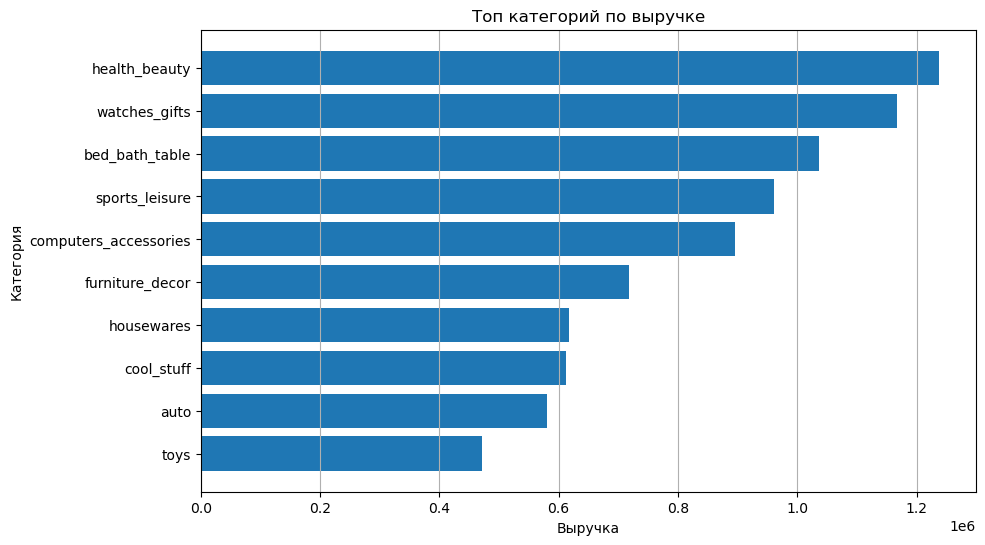

In [14]:
plot_df = top_revenue.sort_values("revenue", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["product_category_name_english"], plot_df["revenue"])
plt.title("Топ категорий по выручке")
plt.xlabel("Выручка")
plt.ylabel("Категория")
plt.grid(axis="x")
plt.show()

## Топ категорий по прокси-оценкe коммерческого вклада

Здесь ранжирует категории по contribution proxy и выявляет категории, которые могут выглядеть более привлекательными финансово, даже если они не входят в число крупнейших по выручке.

In [43]:
top_contribution = category_summary_filtered.sort_values("contribution_proxy", ascending=False).head(10)

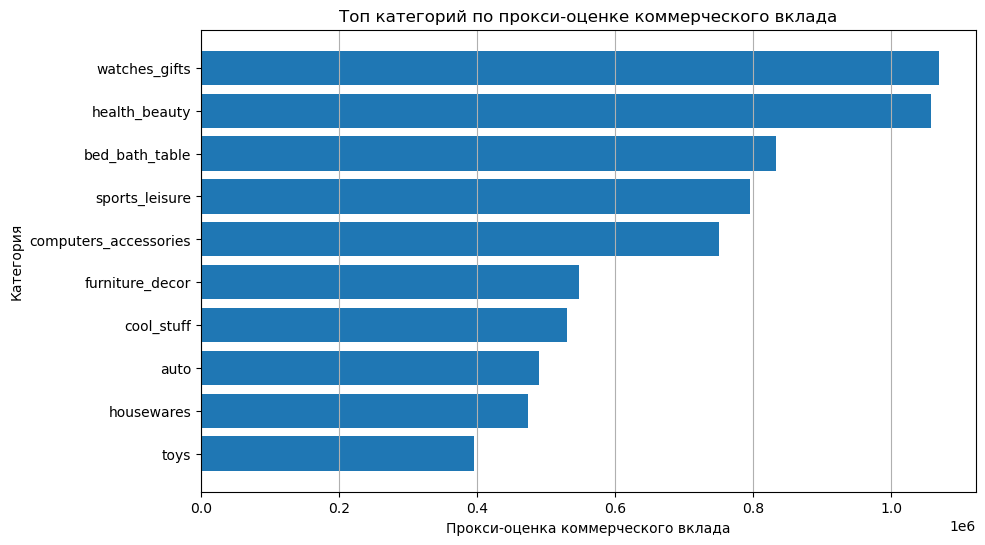

In [63]:
plot_df = top_contribution.sort_values("contribution_proxy", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["product_category_name_english"], plot_df["contribution_proxy"])
plt.title("Топ категорий по прокси-оценкe коммерческого вклада")
plt.xlabel("Прокси-оценка коммерческого вклада")
plt.ylabel("Категория")
plt.grid(axis="x")
plt.show()

Сравнение этого графика с графиком по выручке позволяет увидеть, что категории-лидеры по продажам и категории-лидеры по contribution proxy совпадают не полностью, что подтверждает гипотезу.

## Категории с самой высокой логистической нагрузкой

На данном графике представлены категории, у которых стоимость доставки составляет особенно большую долю от цены товара.

In [44]:
high_freight = category_summary_filtered.sort_values("freight_to_price_pct", ascending=False).head(10)

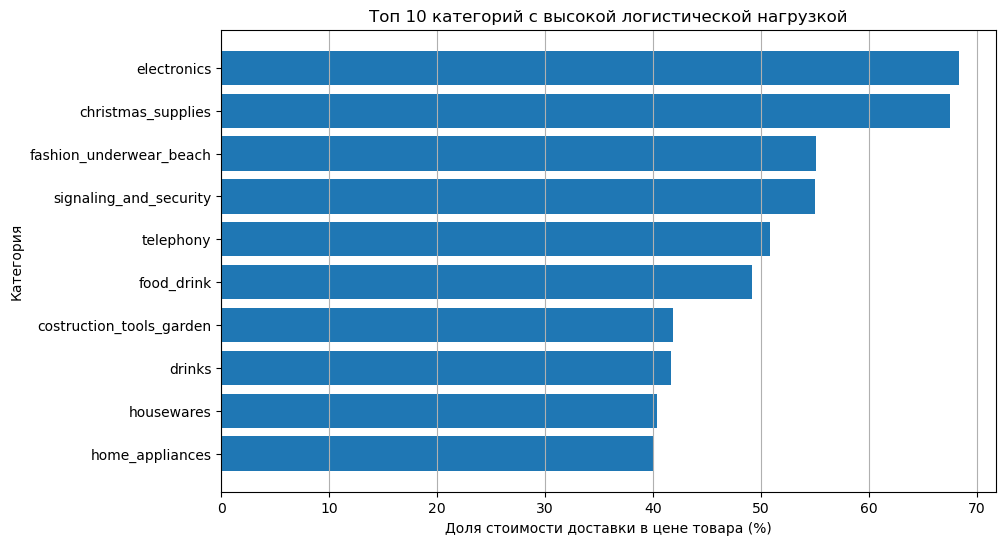

In [66]:
plot_df = high_freight.sort_values("freight_to_price_pct", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["product_category_name_english"], plot_df["freight_to_price_pct"])
plt.title("Топ 10 категорий с высокой логистической нагрузкой")
plt.xlabel("Доля стоимости доставки в цене товара (%)")
plt.ylabel("Категория")
plt.grid(axis="x")
plt.show()

## Категории с самыми низкими клиентскими оценками

Здесь показываются категории, в которых средняя клиентская оценка ниже, чем у остальных.

In [48]:
low_reviews = category_summary_filtered.sort_values("avg_review_score", ascending=True).head(10)

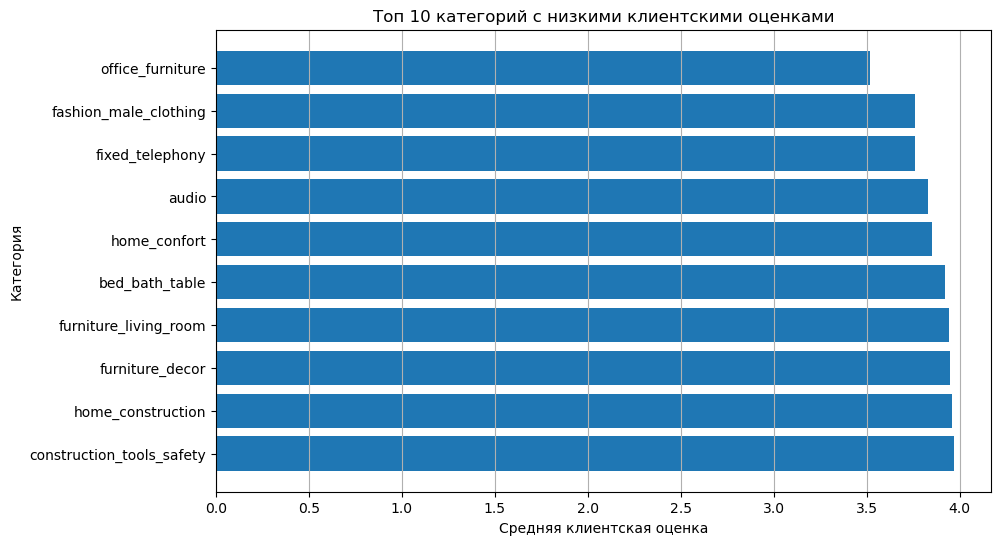

In [67]:
plot_df = low_reviews.sort_values("avg_review_score", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["product_category_name_english"], plot_df["avg_review_score"])
plt.title("Топ 10 категорий с низкими клиентскими оценками")
plt.xlabel("Средняя клиентская оценка")
plt.ylabel("Категория")
plt.grid(axis="x")
plt.show()

## Категории с самой высокой долей опозданий

Эта таблица показывает категории, в которых выше доля заказов, доставленных позже обещанного срока.

In [61]:
late_categories = category_summary_filtered.sort_values("late_delivery_rate", ascending=False).head(10)

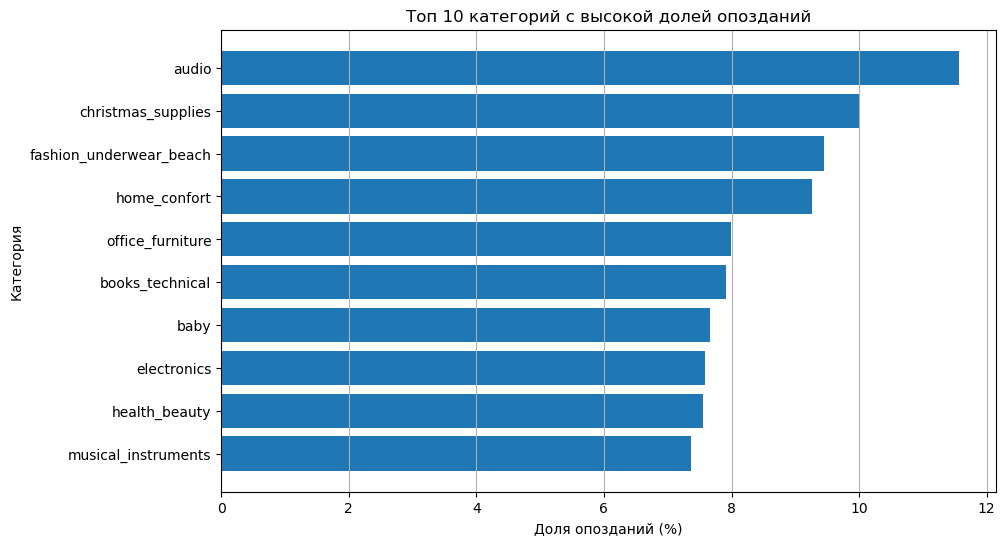

In [68]:
plot_df = late_categories.sort_values("late_delivery_rate", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["product_category_name_english"], plot_df["late_delivery_rate"])
plt.title("Топ 10 категорий с высокой долей опозданий")
plt.xlabel("Доля опозданий (%)")
plt.ylabel("Категория")
plt.grid(axis="x")
plt.show()

## Выделение сильных категорий

Для этого отбираются категории, которые одновременно:
- выше медианы по contribution proxy
- выше медианы по клиентской оценке
- ниже медианы по логистической нагрузке
- ниже медианы по доле опозданий

In [20]:
medians = category_summary_filtered[[
    "revenue",
    "contribution_proxy",
    "freight_to_price_pct",
    "avg_review_score",
    "late_delivery_rate"
]].median()

print(medians)

revenue                 108221.60
contribution_proxy       97932.22
freight_to_price_pct        30.15
avg_review_score             4.09
late_delivery_rate           6.27
dtype: float64


## Таблица `good_candidates`

Эта таблица содержит категории, которые отбираются не по выручке, а по логистической нагрузкеБ клиентской оценкке и т.д. Это позволяет увидеть категории, которые выглядят привлекательно даже в том случае, если они не являются абсолютными лидерами по объему продаж.

In [50]:
good_candidates = category_summary_filtered[
    (category_summary_filtered["contribution_proxy"] > medians["contribution_proxy"]) &
    (category_summary_filtered["avg_review_score"] > medians["avg_review_score"]) &
    (category_summary_filtered["freight_to_price_pct"] < medians["freight_to_price_pct"]) &
    (category_summary_filtered["late_delivery_rate"] < medians["late_delivery_rate"])
].copy()

good_candidates = good_candidates.sort_values("contribution_proxy", ascending=False)


## Категории, которые требуют улучшения перед приоритизацией

Данная группа — это категории, которые важны по выручке, но при этом выглядят слабее по клиентским или операционным метрикам. Таким образом, чтобы их продвигать следует для начала улучшить.

In [51]:
fix_before_promoting = category_summary_filtered[
    (category_summary_filtered["revenue"] > medians["revenue"]) &
    (
        (category_summary_filtered["avg_review_score"] < medians["avg_review_score"]) |
        (category_summary_filtered["late_delivery_rate"] > medians["late_delivery_rate"])
    )
].copy()

fix_before_promoting = fix_before_promoting.sort_values("revenue", ascending=False)


## Категории с низкой приоритизацией

In [52]:
low_priority = category_summary_filtered[
    (category_summary_filtered["revenue"] < medians["revenue"]) &
    (category_summary_filtered["contribution_proxy"] < medians["contribution_proxy"]) &
    (category_summary_filtered["avg_review_score"] < medians["avg_review_score"]) &
    (category_summary_filtered["late_delivery_rate"] > medians["late_delivery_rate"])
].copy()

low_priority = low_priority.sort_values("revenue", ascending=False)


## Многокритериальное ранжирование категорий

В данном блоке строится показатель `promotion_priority_score`.

Этот показатель объединяет несколько измерений:
- contribution proxy
- клиентскую оценку
- логистическую нагрузку
- долю опозданий

In [24]:
scored = category_summary_filtered.copy()

scored["contribution_score"] = (
    (scored["contribution_proxy"] - scored["contribution_proxy"].min()) /
    (scored["contribution_proxy"].max() - scored["contribution_proxy"].min())
)

scored["review_score_norm"] = (
    (scored["avg_review_score"] - scored["avg_review_score"].min()) /
    (scored["avg_review_score"].max() - scored["avg_review_score"].min())
)

scored["freight_score"] = 1 - (
    (scored["freight_to_price_pct"] - scored["freight_to_price_pct"].min()) /
    (scored["freight_to_price_pct"].max() - scored["freight_to_price_pct"].min())
)

scored["late_score"] = 1 - (
    (scored["late_delivery_rate"] - scored["late_delivery_rate"].min()) /
    (scored["late_delivery_rate"].max() - scored["late_delivery_rate"].min())
)

In [25]:
scored["promotion_priority_score"] = (
    0.40 * scored["contribution_score"] +
    0.25 * scored["review_score_norm"] +
    0.20 * scored["freight_score"] +
    0.15 * scored["late_score"]
)

## Итоговая таблица рекомендаций

Данная таблица позволяет выделить предпочтительные категории для для дальнейшего продвижения

In [58]:
final_recommendations = scored[[
    "product_category_name_english",
    "orders_cnt",
    "revenue",
    "contribution_proxy",
    "avg_review_score",
    "freight_to_price_pct",
    "late_delivery_rate",
    "promotion_priority_score"
]].copy()

final_recommendations = final_recommendations.sort_values(
    "promotion_priority_score",
    ascending=False
)

## Таблица final_recommendations
В данной таблице каждой категории присваивается итоговая группа рекомендации:

`Promote` — категории, которые выглядят наиболее сильными по совокупности метрик и могут рассматриваться как приоритетные

`Fix before promoting` — категории, которые коммерчески важны, но требуют улучшения клиентского или операционного профиля перед дальнейшей приоритизацией

`Low priority` — категории с более слабым общим профилем, которые выглядят менее привлекательными для фокуса

`Secondary opportunity` — категории, которые не попали в крайние группы и могут рассматриваться как второстепенные возможности

In [59]:
final_recommendations = final_recommendations.copy()

conditions = [
    final_recommendations["product_category_name_english"].isin(good_candidates["product_category_name_english"]),
    final_recommendations["product_category_name_english"].isin(fix_before_promoting["product_category_name_english"]),
    final_recommendations["product_category_name_english"].isin(low_priority["product_category_name_english"])
]

choices = [
    "Promote",
    "Fix before promoting",
    "Low priority"
]

final_recommendations["recommendation_group"] = np.select(
    conditions,
    choices,
    default="Secondary opportunity"
)

final_recommendations.head(10)

,product_category_name_english,orders_cnt,revenue,contribution_proxy,avg_review_score,freight_to_price_pct,late_delivery_rate,promotion_priority_score,recommendation_group
70,watches_gifts,5495,1167246.63,1068940.35,4.07,17.14,7.21,0.776284,Fix before promoting
43,health_beauty,8647,1237439.95,1057610.91,4.19,30.15,7.56,0.754887,Fix before promoting
65,sports_leisure,7530,960189.09,795740.75,4.17,29.35,6.27,0.675774,Secondary opportunity
7,bed_bath_table,9272,1037177.69,832865.60,3.92,28.37,7.03,0.616837,Fix before promoting
20,cool_stuff,3559,612071.86,530421.78,4.19,22.01,5.82,0.612073,Promote
15,computers_accessories,6530,896243.28,751172.29,3.98,29.40,6.46,0.607646,Fix before promoting
14,computers,177,218684.14,209018.52,4.22,5.67,5.03,0.564277,Promote
69,toys,3804,472109.78,396220.48,4.21,26.51,6.39,0.542617,Fix before promoting
49,housewares,5743,617836.73,474618.03,4.11,40.38,4.99,0.526367,Secondary opportunity
5,auto,3810,580263.44,489506.91,4.12,33.26,7.02,0.522758,Fix before promoting


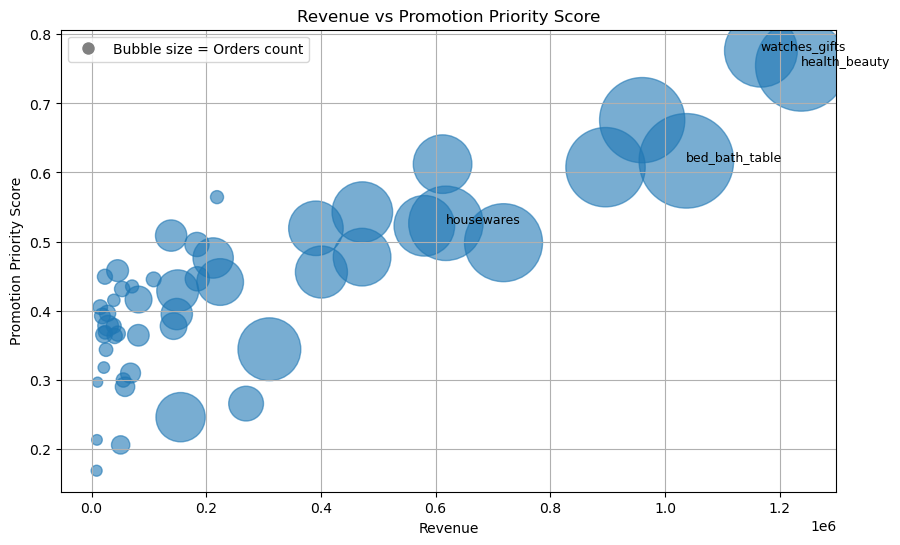

In [27]:
scatter_df = final_recommendations.copy()

plt.figure(figsize=(10, 6))
plt.scatter(
    scatter_df["revenue"],
    scatter_df["promotion_priority_score"],
    s=scatter_df["orders_cnt"] * 0.5,
    alpha=0.6,
    label="Category"
)

highlight_categories = [
    "watches_gifts",
    "health_beauty",
    "bed_bath_table",
    "housewares"
]

for _, row in scatter_df[scatter_df["product_category_name_english"].isin(highlight_categories)].iterrows():
    plt.annotate(
        row["product_category_name_english"],
        (row["revenue"], row["promotion_priority_score"]),
        fontsize=9
    )

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Bubble size = Orders count',
           markerfacecolor='gray', markersize=10)
]

plt.title("Revenue vs Promotion Priority Score")
plt.xlabel("Revenue")
plt.ylabel("Promotion Priority Score")
plt.legend(handles=legend_elements, loc="best")
plt.grid(True)
plt.show()

### Вывод по графику 

График показывает, что высокий уровень выручки не всегда сопровождается столь же высокой итоговой многокритериальной оценкой.

Если бы приоритизация категорий полностью совпадала с ранжированием по выручке, то категории с самым высоким revenue систематически занимали бы и самые высокие позиции по `promotion_priority_score`. Однако визуально видно, что это совпадение не является полным: часть категорий со средним revenue поднимается выше по совокупности метрик score.

Таким образом, выручка и общая привлекательность категории связаны, но не совпадают полностью.

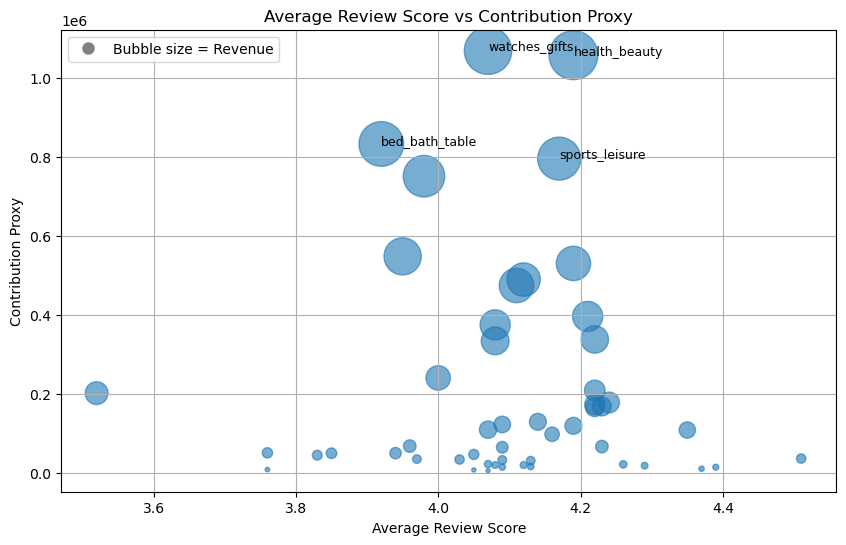

In [37]:
scatter_df = category_summary_filtered.copy()

plt.figure(figsize=(10, 6))
plt.scatter(
    scatter_df["avg_review_score"],
    scatter_df["contribution_proxy"],
    s=scatter_df["revenue"] / 1000,
    alpha=0.6,
    label="Category"
)

highlight_categories = [
    "watches_gifts",
    "health_beauty",
    "sports_leisure",
    "bed_bath_table"
]

for _, row in scatter_df[scatter_df["product_category_name_english"].isin(highlight_categories)].iterrows():
    plt.annotate(
        row["product_category_name_english"],
        (row["avg_review_score"], row["contribution_proxy"]),
        fontsize=9
    )

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Bubble size = Revenue',
           markerfacecolor='gray', markersize=10)
]

plt.title("Average Review Score vs Contribution Proxy")
plt.xlabel("Average Review Score")
plt.ylabel("Contribution Proxy")
plt.legend(handles=legend_elements, loc="best")
plt.grid(True)
plt.show()

### Вывод по графику 

График позволяет выделить категории, которые выглядят сильными одновременно по коммерческому вкладу и по качеству клиентского опыта.

Наиболее сильной категорией на графике выглядит `watches_gifts`: она находится в зоне высокого коммерческого вклада и при этом сохраняет достаточно высокий review score. Это делает ее особенно интересной как пример категории, которая сочетает сильную экономику и хороший клиентский профиль.

`health_beauty` и `sports_leisure` также выглядят привлекательно: они занимают высокие позиции по contribution proxy и при этом не проседают по клиентской оценке. Эти категории можно интерпретировать как более сбалансированные по совокупности коммерческих и клиентских характеристик.

В то же время `bed_bath_table`, несмотря на высокий коммерческий масштаб, выглядит слабее с точки зрения клиентской оценки по сравнению с рядом других сильных категорий. Это означает, что высокая коммерческая значимость категории не всегда сопровождается столь же сильным клиентским профилем.

Таким образом, график показывает, что категории с сильной экономикой и категории с наиболее качественным клиентским профилем совпадают не полностью, а значит для приоритизации недостаточно смотреть только на продажи.

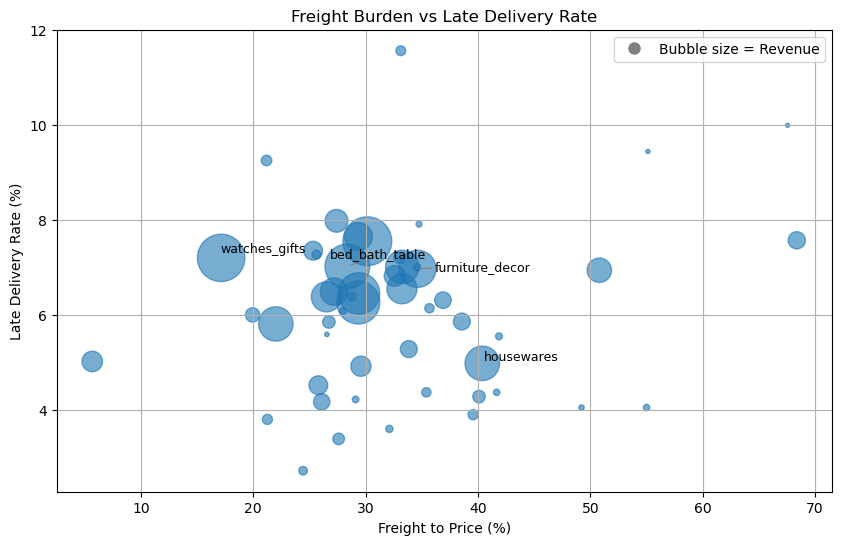

In [41]:
from matplotlib.lines import Line2D
from adjustText import adjust_text
import matplotlib.pyplot as plt

scatter_df = category_summary_filtered.copy()

plt.figure(figsize=(10, 6))
plt.scatter(
    scatter_df["freight_to_price_pct"],
    scatter_df["late_delivery_rate"],
    s=scatter_df["revenue"] / 1000,
    alpha=0.6
)

highlight_categories = [
    "housewares",
    "furniture_decor",
    "bed_bath_table",
    "watches_gifts"
]

texts = []

for _, row in scatter_df[scatter_df["product_category_name_english"].isin(highlight_categories)].iterrows():
    texts.append(
        plt.text(
            row["freight_to_price_pct"],
            row["late_delivery_rate"],
            row["product_category_name_english"],
            fontsize=9
        )
    )

adjust_text(
    texts,
    arrowprops=dict(arrowstyle="-", color="gray", lw=0.8)
)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Bubble size = Revenue',
           markerfacecolor='gray', markersize=10)
]

plt.title("Freight Burden vs Late Delivery Rate")
plt.xlabel("Freight to Price (%)")
plt.ylabel("Late Delivery Rate (%)")
plt.legend(handles=legend_elements, loc="best")
plt.grid(True)
plt.show()

### Вывод по графику 

Категории, расположенные ближе к правому верхнему углу, выглядят слабее с точки зрения операционной устойчивости: у них выше логистическая нагрузка (доля логистических затрат в цене товара) и выше доля задержек.

График показывает заметные различия между категориями по операционному профилю.

`housewares` и `furniture_decor` выглядят более проблемными категориями: у них выше логистическая нагрузка, а также более слабый профиль по доле опозданий. Это означает, что даже если такие категории заметны по продажам, их операционная устойчивость выглядит слабее, а значит их приоритизация требует большей осторожности.

`bed_bath_table` коммерчески очень значима, однако на графике она также не выглядит одной из самых устойчивых категорий с точки зрения логистики и исполнения. Это важно, потому что категория может быть крупной по выручке, но не обязательно оптимальной для дальнейшего фокуса, если учитывать операционные ограничения.

На этом фоне `watches_gifts` выглядит сильнее: категория показывает более умеренную логистическую нагрузку и более спокойный операционный профиль по сравнению с частью других заметных категорий. Это делает ее более сбалансированным кандидатом для приоритизации.

Таким образом, график подтверждает, что категории с высоким коммерческим потенциалом могут существенно различаться по операционной устойчивости, и именно поэтому выручка сама по себе не дает полной картины.

## Таблица `rank_comparison`

Таблица `rank_comparison` сопоставляет позицию каждой категории в двух рейтингах:

- `rank_by_revenue` — место категории в ранжировании по выручке;
- `rank_by_score` — место категории в ранжировании по многокритериальному score;
- `rank_diff` — разница между этими двумя позициями.

Положительный `rank_diff` означает, что категория выглядит сильнее по многокритериальной оценке, чем по выручке.  
Отрицательный `rank_diff` означает, что категория выглядит сильнее по выручке, чем по многокритериальной оценке.

Таким образом, эта таблица позволяет увидеть, какие категории оказываются недооцененными или переоцененными, если смотреть только на объем продаж.

In [53]:
revenue_rank = category_summary_filtered[[
    "product_category_name_english",
    "revenue"
]].sort_values("revenue", ascending=False).reset_index(drop=True)

revenue_rank["rank_by_revenue"] = revenue_rank.index + 1

score_rank = final_recommendations[[
    "product_category_name_english",
    "promotion_priority_score"
]].sort_values("promotion_priority_score", ascending=False).reset_index(drop=True)

score_rank["rank_by_score"] = score_rank.index + 1

rank_comparison = revenue_rank.merge(
    score_rank,
    on="product_category_name_english",
    how="inner"
)

rank_comparison["rank_diff"] = (
    rank_comparison["rank_by_revenue"] - rank_comparison["rank_by_score"]
)


## Категории, недооцененные и переоценные при ранжировании только по выручке

В певой таблице категории можно рассматривать как потенциально недооцененные кандидаты для более внимательной приоритизации. Вторая таблица помогает выявить категории, которые не стоит автоматически считать лучшими объектами для приоритизации только потому, что они много продаются.

In [30]:
most_underrated = rank_comparison.sort_values("rank_diff", ascending=False).head(10)
most_overrated = rank_comparison.sort_values("rank_diff", ascending=True).head(10)

display(most_underrated)
most_overrated

,product_category_name_english,revenue,rank_by_revenue,promotion_priority_score,rank_by_score,rank_diff
43,fashion_shoes,23206.16,44,0.449037,19,25
47,food_drink,15033.87,48,0.405092,28,20
35,books_general_interest,45302.15,36,0.457856,17,19
46,books_technical,18755.20,47,0.392252,31,16
24,luggage_accessories,138701.63,25,0.508630,12,13
40,market_place,27795.77,41,0.395987,29,12
37,construction_tools_safety,38773.22,38,0.414891,27,11
16,computers,218684.14,17,0.564277,7,10
32,air_conditioning,53323.56,33,0.431298,24,9
42,art,23657.30,43,0.368609,35,8


,product_category_name_english,revenue,rank_by_revenue,promotion_priority_score,rank_by_score,rank_diff
14,office_furniture,269418.10,15,0.265325,47,-32
20,electronics,155173.83,21,0.245680,48,-27
13,telephony,310004.11,14,0.344042,40,-26
33,audio,50620.50,34,0.205502,50,-16
30,home_confort,58265.15,31,0.289697,46,-15
29,furniture_living_room,67861.40,30,0.309505,43,-13
31,fixed_telephony,55355.20,32,0.299484,44,-12
23,construction_tools_construction,142940.29,24,0.377510,34,-10
27,home_construction,81527.42,28,0.364278,38,-10
22,consoles_games,148538.37,23,0.394971,30,-7


## Вывод

Проанализировав данные таблицы видим, что в них категории не совпадают, следовательно, приоритизация только по выручке действительно приводит к иному результату, чем многокритериальный подход, что подтверждает сформулированную изначально гипотезу.

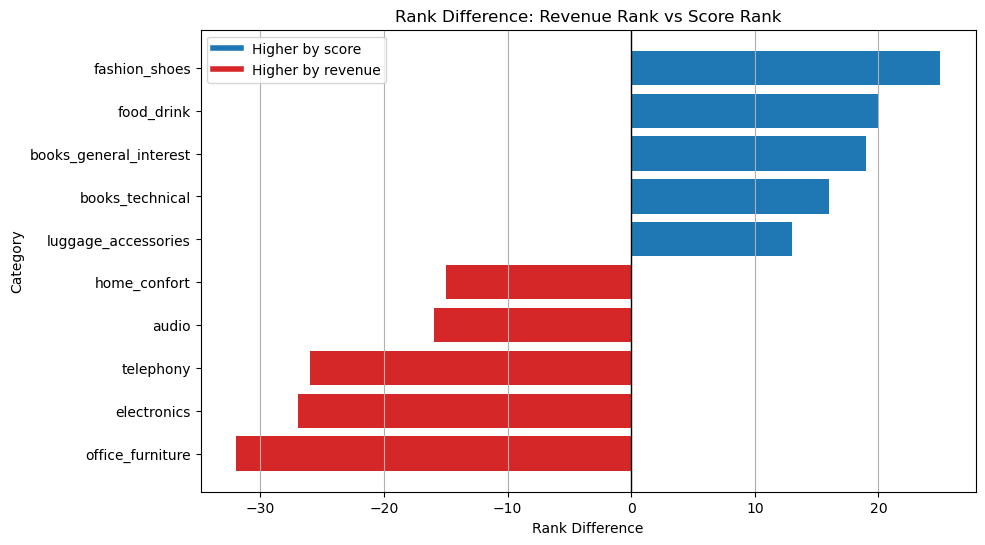

In [31]:
rank_plot = pd.concat([
    rank_comparison.sort_values("rank_diff", ascending=False).head(5),
    rank_comparison.sort_values("rank_diff", ascending=True).head(5)
])

rank_plot = rank_plot.drop_duplicates(subset=["product_category_name_english"]).copy()
rank_plot = rank_plot.sort_values("rank_diff", ascending=True)

colors = ["tab:red" if x < 0 else "tab:blue" for x in rank_plot["rank_diff"]]

plt.figure(figsize=(10, 6))
plt.barh(rank_plot["product_category_name_english"], rank_plot["rank_diff"], color=colors)
plt.axvline(0, color="black", linewidth=1)

legend_elements = [
    Line2D([0], [0], color='tab:blue', lw=4, label='Higher by score'),
    Line2D([0], [0], color='tab:red', lw=4, label='Higher by revenue')
]

plt.title("Rank Difference: Revenue Rank vs Score Rank")
plt.xlabel("Rank Difference")
plt.ylabel("Category")
plt.legend(handles=legend_elements, loc="best")
plt.grid(axis="x")
plt.show()

### Вывод по графику 

Этот график опдтверждает гипотезу: если бы ранжирование по выручке и ранжирование по многокритериальному score давали одинаковый результат, значения `rank_diff` были бы близки к нулю для большинства категорий. Однако график показывает заметные смещения: часть категорий оказывается недооцененной при анализе только по revenue, тогда как другие категории, наоборот, выглядят переоцененными, если ориентироваться только на объем продаж.

Это означает, что ранжирование только по выручке действительно приводит к иному списку приоритетов, чем ранжирование по более широкому набору метрик.

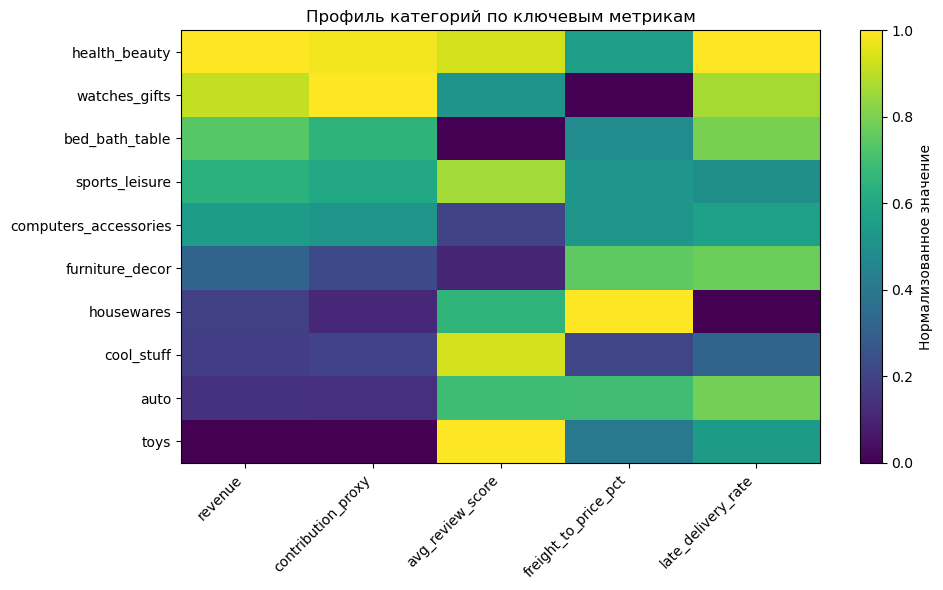

In [69]:
heatmap_df = category_summary_filtered.sort_values("revenue", ascending=False).head(10).copy()
heatmap_df = heatmap_df.set_index("product_category_name_english")[
    ["revenue", "contribution_proxy", "avg_review_score", "freight_to_price_pct", "late_delivery_rate"]
]

heatmap_norm = (heatmap_df - heatmap_df.min()) / (heatmap_df.max() - heatmap_df.min())

plt.figure(figsize=(10, 6))
plt.imshow(heatmap_norm, aspect="auto")
plt.colorbar(label="Нормализованное значение")
plt.xticks(range(len(heatmap_norm.columns)), heatmap_norm.columns, rotation=45, ha="right")
plt.yticks(range(len(heatmap_norm.index)), heatmap_norm.index)
plt.title("Профиль категорий по ключевым метрикам")
plt.tight_layout()
plt.show()

### Вывод по графику
Данный график нужен для того, чтобы посмотреть на категории не по одной метрике, а сразу по нескольким.

Здесь одновременно сравниваются:
- выручка
- прокси-оценка вклада
- средняя клиентская оценка
- логистическая нагрузка
- доля опозданий

Тепловая карта показывает, что категории имеют неоднородный профиль: одни выглядят сильнее по выручке, другие — по прокси-оценке вклада, третьи — по отзывам или операционной устойчивости.

Это важно для гипотезы проекта, потому что показывает: привлекательность категории нельзя описать одной метрикой. Если бы выручка действительно отражала общую силу категории, то лидеры по revenue выглядели бы сильными и по остальным показателям. Однако график показывает, что это не так: часть категорий оказывается сильной по одним параметрам и слабой по другим.

Следовательно, многокритериальный подход к оценке категорий выглядит более обоснованным, чем ранжирование только по продажам.

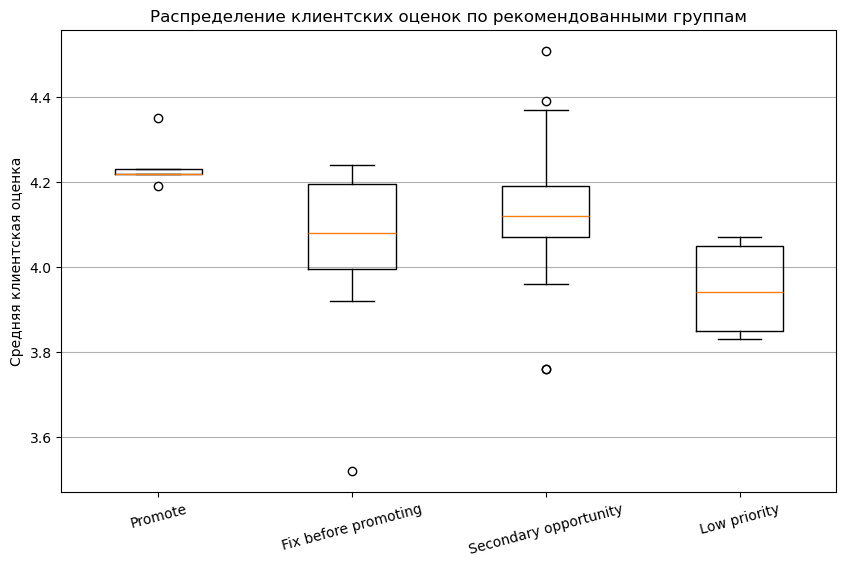

In [74]:
merged_groups = category_summary_filtered.merge(
    final_recommendations[["product_category_name_english", "recommendation_group"]],
    on="product_category_name_english",
    how="left"
)

groups = ["Promote", "Fix before promoting", "Secondary opportunity", "Low priority"]
data = [
    merged_groups.loc[merged_groups["recommendation_group"] == g, "avg_review_score"].dropna()
    for g in groups
]

plt.figure(figsize=(10, 6))
plt.boxplot(data, tick_labels=groups)
plt.title("Распределение клиентских оценок по рекомендованными группам")
plt.ylabel("Средняя клиентская оценка")
plt.xticks(rotation=15)
plt.grid(axis="y")
plt.show()

### Вывод по графику

После того как категории были распределены по итоговым рекомендационным группам, важно проверить, действительно ли эти группы отличаются между собой по клиентскому профилю.

Этот график показывает распределение средней клиентской оценки внутри каждой рекомендационной группы.

Если распределение review score у группы `Promote` смещено выше, чем у остальных групп, это означает, что итоговая приоритизация действительно выделяет категории с более сильным клиентским профилем.

В таком случае график показывает, что recommendation groups не являются формальной классификацией “ради удобства”, а отражают реальные различия между категориями. Категории, рекомендованные к приоритизации, не только сильнее по score, но и в среднем лучше воспринимаются клиентами.

Если же группы почти не различаются по review score, это означало бы, что клиентская оценка не играет большой роли в итоговом разделении категорий.

На графике видно, что категории из группы `Promote` в среднем имеют более высокие клиентские оценки, чем категории из групп `Fix before promoting` и `Low priority`. Это означает, что в итоговую приоритетную группу действительно попадают категории с более сильным клиентским профилем, а не просто категории с высоким объемом продаж.

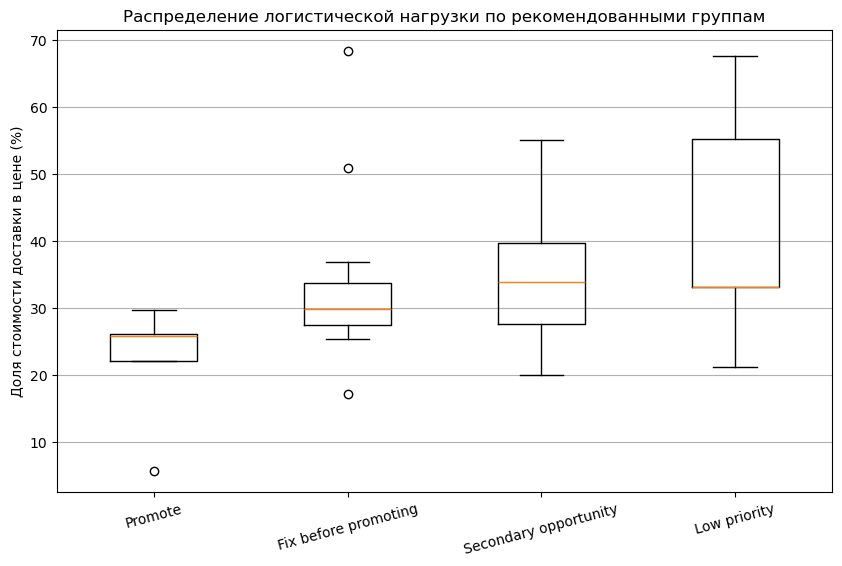

In [75]:
data = [
    merged_groups.loc[merged_groups["recommendation_group"] == g, "freight_to_price_pct"].dropna()
    for g in groups
]

plt.figure(figsize=(10, 6))
plt.boxplot(data, tick_labels=groups)
plt.title("Распределение логистической нагрузки по рекомендованными группам")
plt.ylabel("Доля стоимости доставки в цене (%)")
plt.xticks(rotation=15)
plt.grid(axis="y")
plt.show()

In [ ]:
### Вывод по графику
Следующий график показывает, как рекомендационные группы различаются по логистической нагрузке.

В данном случае под логистической нагрузкой понимается доля стоимости доставки в цене товара (`freight_to_price_pct`).

Если у группы `Promote` логистическая нагрузка в среднем ниже, чем у групп `Fix before promoting` и `Low priority`, это означает, что итоговая приоритизация действительно выделяет категории с более благоприятной экономикой исполнения.

Такой результат важен, потому что показывает: в приоритетную группу попадают не просто категории с сильными продажами, а категории, рост которых потенциально меньше отягощен логистическими затратами.

Если же распределения между группами выглядят одинаково, это означало бы, что логистическая нагрузка почти не влияет на итоговую классификацию.

График показывает, что категории из группы `Promote` в среднем имеют более низкую долю логистических затрат в цене товара, чем категории из менее привлекательных групп. Это означает, что итоговая приоритизация не только учитывает продажи, но и фактически выделяет категории с более устойчивой экономикой исполнения.

In [34]:
top10_revenue = set(revenue_rank.head(10)["product_category_name_english"])
top10_score = set(score_rank.head(10)["product_category_name_english"])

overlap = top10_revenue.intersection(top10_score)

print("Top-10 by revenue:", top10_revenue)
print("Top-10 by score:", top10_score)
print("Overlap:", overlap)
print("Overlap count:", len(overlap))

Top-10 by revenue: {'cool_stuff', 'watches_gifts', 'auto', 'bed_bath_table', 'sports_leisure', 'toys', 'furniture_decor', 'computers_accessories', 'housewares', 'health_beauty'}
Top-10 by score: {'watches_gifts', 'computers', 'auto', 'bed_bath_table', 'sports_leisure', 'computers_accessories', 'toys', 'cool_stuff', 'housewares', 'health_beauty'}
Overlap: {'cool_stuff', 'watches_gifts', 'auto', 'bed_bath_table', 'sports_leisure', 'toys', 'computers_accessories', 'housewares', 'health_beauty'}
Overlap count: 9


## Вывод

Сравнение ранжирования по выручке и по многокритериальному score показывает, что категории-лидеры по продажам не полностью совпадают с категориями, которые выглядят наиболее привлекательными по совокупности рассмотренных выше бизнес-метрик.

Так, наиболее сильными кандидатами для приоритизации являются `watches_gifts`, `health_beauty`, `sports_leisure` и `cool_stuff`. Эти категории сочетают высокий contribution proxy с достаточно хорошим клиентским и операционным профилем. Особенно выделяется `watches_gifts`: категория показывает один из самых высоких contribution proxy при относительно низкой логистической нагрузке.

В то же время часть категорий, заметных по выручке, выглядит менее привлекательной при более широком подходе к оценке. Например, `housewares` и `furniture_decor` характеризуются более высокой логистической нагрузкой, а `bed_bath_table`, несмотря на высокий коммерческий масштаб, показывает более слабую клиентскую оценку по сравнению с рядом других сильных категорий.

Таким образом, изначально сформулированная гипотеза принимается: выручка сама по себе недостаточна для приоритизации категорий, а более обоснованный подход должен учитывать также contribution proxy, клиентскую оценку и операционную устойчивость.